Setup & Load MNIST Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import fetch_openml
import wandb

# Inisialisasi W&B
# Log konfigurasi model di sini agar bisa dilacak di W&B
config = {
    "project": "mnist-neural-networks",
    "name": "mlp-larger-hidden-layers",
    "hidden_layer_sizes": (256, 128), # Akan kita ubah nanti
    "activation": "relu",
    "solver": "adam",
    "learning_rate_init": 0.001,
    "alpha": 0.0001,
    "max_iter": 200
}

run = wandb.init(project=config["project"], name=config["name"], config=config)

# Load MNIST Dataset (Angka 0-9)
print("Loading MNIST data... (Mohon tunggu)")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Normalisasi: Mengubah rentang pixel 0-255 menjadi 0-1 agar NN belajar lebih cepat
X = X / 255.0

print(f"Data Loaded. Shape: {X.shape}")

Loading MNIST data... (Mohon tunggu)
Data Loaded. Shape: (70000, 784)


Visualisasi Data Tulisan Tangan

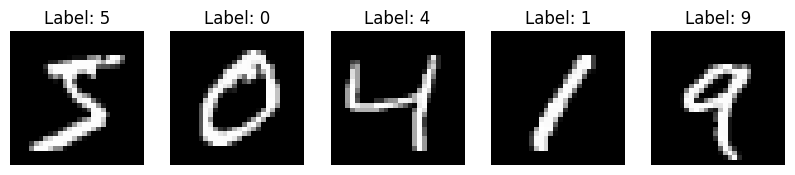

In [4]:
# Mari kita lihat apa yang dilihat oleh AI
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

# Log contoh gambar ke W&B
wandb.log({"mnist_examples": [wandb.Image(X[i].reshape(28, 28), caption=f"Label: {y[i]}") for i in range(5)]})

Pelatihan Multi-Layer Perceptron

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Arsitektur Jaringan Saraf
# hidden_layer_sizes=(256, 128) artinya ada 2 hidden layer dengan 256 dan 128 neuron
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), # Mengubah ukuran hidden layer
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.001, # Kecepatan belajar awal
                    alpha=0.0001, # Tambahkan ini: L2 Penalty (Regularisasi)
                    max_iter=200, # Meningkatkan iterasi untuk pelatihan yang lebih baik
                    verbose=True,
                    random_state=42)

print("Melatih Jaringan Saraf...")
mlp.fit(X_train, y_train)

Melatih Jaringan Saraf...
Iteration 1, loss = 0.31092157
Iteration 2, loss = 0.11825392
Iteration 3, loss = 0.07698668
Iteration 4, loss = 0.05623950
Iteration 5, loss = 0.04196144
Iteration 6, loss = 0.03158407
Iteration 7, loss = 0.02516187
Iteration 8, loss = 0.01955886
Iteration 9, loss = 0.01432945
Iteration 10, loss = 0.01121510
Iteration 11, loss = 0.01178695
Iteration 12, loss = 0.00905730
Iteration 13, loss = 0.00625935
Iteration 14, loss = 0.00332598
Iteration 15, loss = 0.00379349
Iteration 16, loss = 0.01577095
Iteration 17, loss = 0.01008100
Iteration 18, loss = 0.01065996
Iteration 19, loss = 0.00557114
Iteration 20, loss = 0.00217361
Iteration 21, loss = 0.00359275
Iteration 22, loss = 0.01138800
Iteration 23, loss = 0.00812802
Iteration 24, loss = 0.00460386
Iteration 25, loss = 0.00606172
Iteration 26, loss = 0.00727244
Iteration 27, loss = 0.00448570
Iteration 28, loss = 0.00208385
Iteration 29, loss = 0.00429740
Iteration 30, loss = 0.00497539
Iteration 31, loss = 0.

MLPClassifier(hidden_layer_sizes=(256, 128), random_state=42, verbose=True)

Evaluasi & Tracking W&B

In [6]:
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Log kurva kehilangan (Loss Curve) yang menunjukkan proses belajar
for i, loss in enumerate(mlp.loss_curve_):
    wandb.log({"loss": loss, "epoch": i})

wandb.log({"Final_Accuracy": acc})

print(f"\nAkurasi MLP: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Akurasi MLP: 0.9771

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.98      0.97      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.98      0.97      0.98      1295
           5       0.97      0.98      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.98      0.98      0.98      1503
           8       0.97      0.96      0.97      1357
           9       0.96      0.97      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



Analisis Kesalahan (Confusion Matrix)

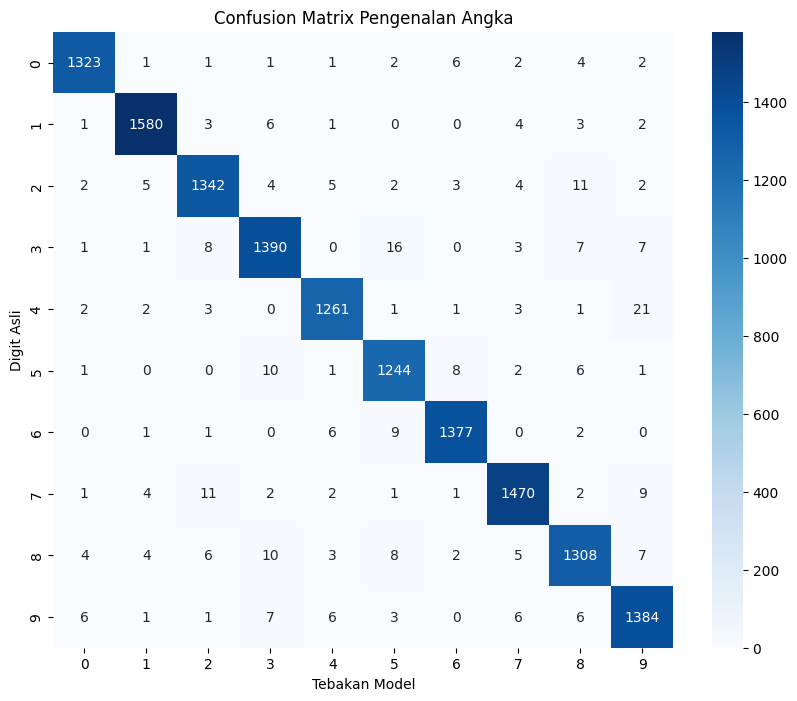

Final_Accuracy,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
loss,█▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁
Final_Accuracy,0.97707
epoch,42
loss,0.00124


In [7]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tebakan Model')
plt.ylabel('Digit Asli')
plt.title('Confusion Matrix Pengenalan Angka')
plt.show()

wandb.finish()